# Stellar Classification and Supervised Learning
This notebook demonstrates how to build, train, and evaluate multiple models (both traditional ML and PyTorch Neural Networks) using our custom `stellar_classification` package.

In [1]:
import sys
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20

In [2]:
# Load dataset
data_path = '/home/sara/lcpB/Computational-Physics-2026/Astrophysical-Objects-Recognition/stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

# Color indexes 
star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]

star.info()

First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7)

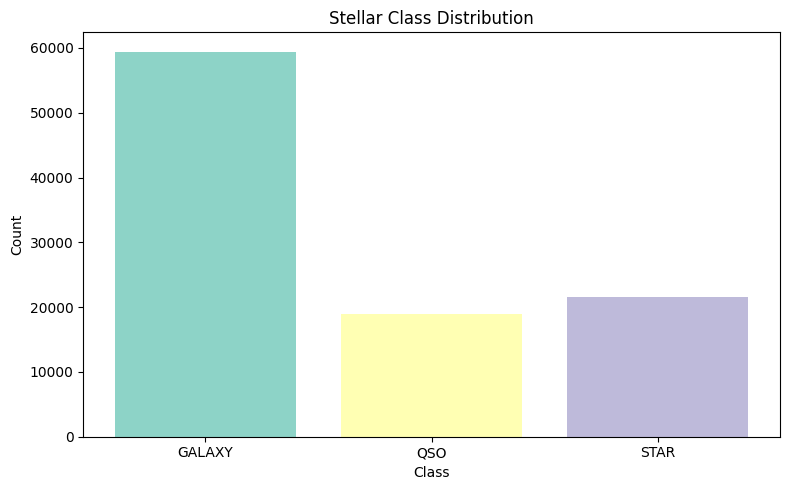

In [3]:
# Visualize Class Distribution
sc.plot_class_distribution(star['class'], title="Stellar Class Distribution")


In [4]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


Outliers removed: 8,715 rows  (91,285 remain)
X_train shape: (97032, 13)
X_val shape: (18257, 13)
X_test shape: (18257, 13)


In [5]:
# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=64
)

print("DataLoaders created.")


DataLoaders created.


In [6]:
# dataframe completo con target
X_full = pd.DataFrame(X_test, columns=feature_names)
X_full["class"] = label_encoder.inverse_transform(y_test)

# feature colore
color_features = ["u_g", "g_r", "r_i", "i_z"]

# media dei colori per classe
color_table = X_full.groupby("class")[color_features].mean()

print(color_table)

             u_g       g_r       r_i       i_z
class                                         
GALAXY  0.213888  0.492081  0.453777  0.369712
QSO    -0.807408 -1.013359 -0.863616 -0.505106
STAR    0.114865 -0.504203 -0.510716 -0.542782


In [7]:
# Train and evaluate traditional ML models
#models = sc.train_traditional(X_train, y_train, X_val, y_val)

In [8]:
# Train Voting Classifier utilizing the trained models
#voting_clf = sc.train_voting(X_train, y_train, X_val, y_val, models=models)
#y_test_pred_voting = voting_clf.predict(X_test)
#voting_metrics = sc.evaluate_test_set(y_test, y_test_pred_voting, "Voting Classifier")

In [9]:
# Confusion Matrices
#class_names = list(label_encoder.classes_)
#sc.plot_confusion_matrix(voting_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Voting Classifier')

In [10]:
# Feature Importance (using permutation importance on the Voting Classifier)
#imp = sc.compute_permutation_importance(voting_clf, X_test, y_test, feature_names=feature_names)
#sc.plot_permutation_importance(imp, top_n=10)

#print("Feature Importance Scores:")
#for feat, val in imp.items():
 #   print(f"{feat}: {val:.4f}")


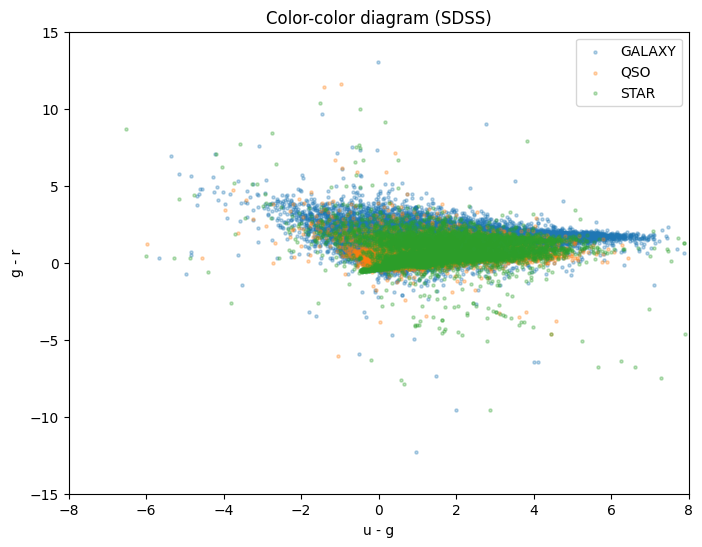

In [11]:
star = pd.read_csv(data_path)

# pulizia minima (fondamentale)
star = star.dropna(subset=['u','g','r','class'])

# indici di colore
star['u_g'] = star['u'] - star['g']
star['g_r'] = star['g'] - star['r']

plt.figure(figsize=(8,6))

for c in star['class'].unique():
    subset = star[star['class'] == c]
    plt.scatter(subset['u_g'], subset['g_r'],
                label=c,
                s=5,
                alpha=0.3)
    plt.xlim(-8, 8)
    plt.ylim(-15, 15)

plt.xlabel('u - g')
plt.ylabel('g - r')
plt.legend()
plt.title('Color-color diagram (SDSS)')
plt.show()

## XGBoost

In [12]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_jobs=3)

params = {"n_estimators": [30, 50],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10],
}

best_model_xgb, best_params_xgb, best_score_xgb = sc.tune_model(
    xgb,
    params,
    X_train,
    y_train,
)

print("Best Hyperparameters:", best_params_xgb)

Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 30, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 1.0}


In [13]:
best_params_xgb.pop("n_estimators", None)

xgb_final = XGBClassifier(**best_params_xgb,n_estimators=1000, objective="multi:softprob",
    eval_metric="mlogloss",
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=42)
xgb_final.fit(X_train, y_train,eval_set=[(X_val, y_val)],verbose=False)

train_metrics_xgb, val_metrics_xgb = sc.evaluate_single_model(
    xgb_final,
    X_train, y_train,
    X_val, y_val,
    model_name="XGBoost Tuned"
)

y_test_pred_xgb = xgb_final.predict(X_test)
xgb_metrics = sc.evaluate_test_set(y_test, y_test_pred_xgb, "XGBoost")
sc.print_metrics(xgb_metrics)
X_test_df = pd.DataFrame(X_test, columns=feature_names)


[Training] Acc=95.4386% P=0.9544 R=0.9544 F1=0.9544
Confusion Matrix:
[[31185   678   481]
 [  982 30656   706]
 [  651   928 30765]]

[Validation] Acc=90.5023% P=0.8761 R=0.8814 F1=0.8783
Confusion Matrix:
[[10173   353   255]
 [  226  3082   240]
 [  276   384  3268]]


XGBoost:
  Accuracy  : 90.90%
  Precision: 0.8807
  Recall   : 0.8859
  F1       : 0.8830
  Confusion Matrix:
[[10203   337   241]
 [  225  3075   248]
 [  248   362  3318]]


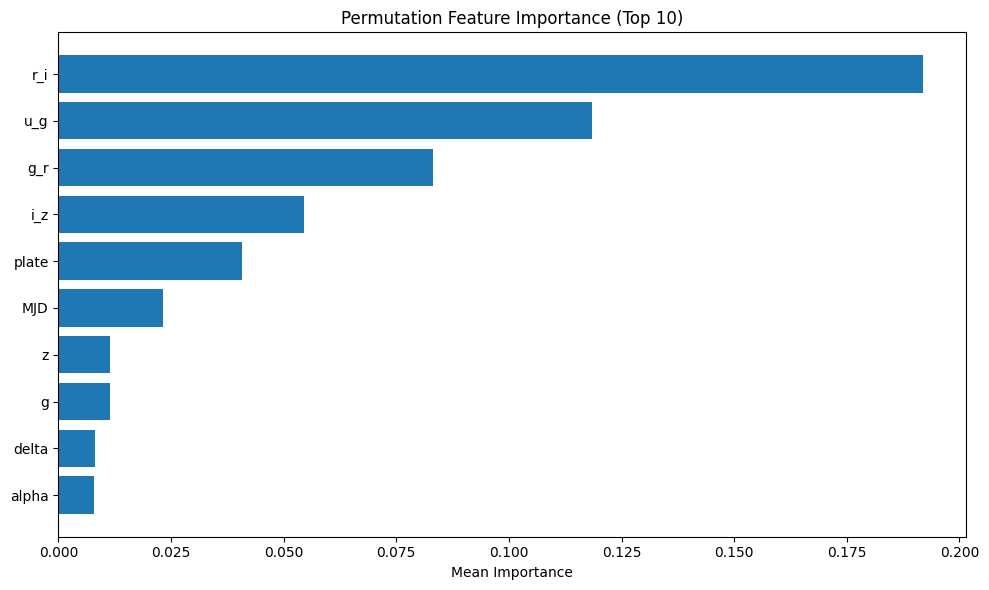

Feature Importance Scores:
r_i: 0.1918
u_g: 0.1185
g_r: 0.0831
i_z: 0.0546
plate: 0.0408
MJD: 0.0231
z: 0.0114
g: 0.0114
delta: 0.0081
alpha: 0.0078
r: 0.0056
i: 0.0037
u: 0.0016


In [14]:
# Feature Importance (using permutation importance on the XGBoost Classifier)
imp_xgb = sc.compute_permutation_importance(xgb_final, X_test, y_test, feature_names=feature_names)
sc.plot_permutation_importance(imp_xgb, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp_xgb.items():
    print(f"{feat}: {val:.4f}")


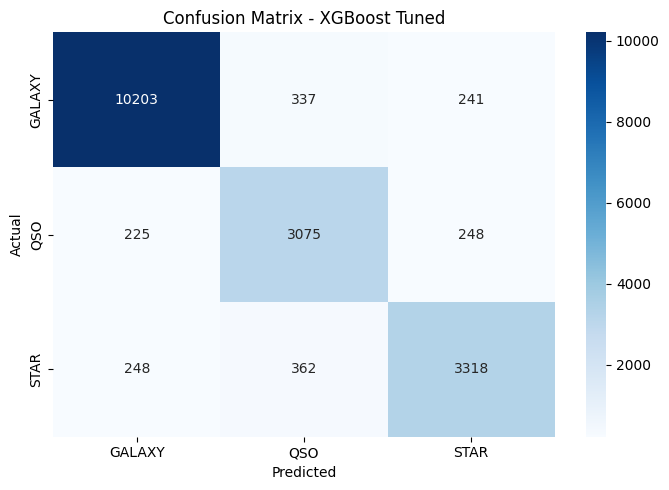

In [15]:
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(xgb_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - XGBoost Tuned')


SHAP summary for class: GALAXY


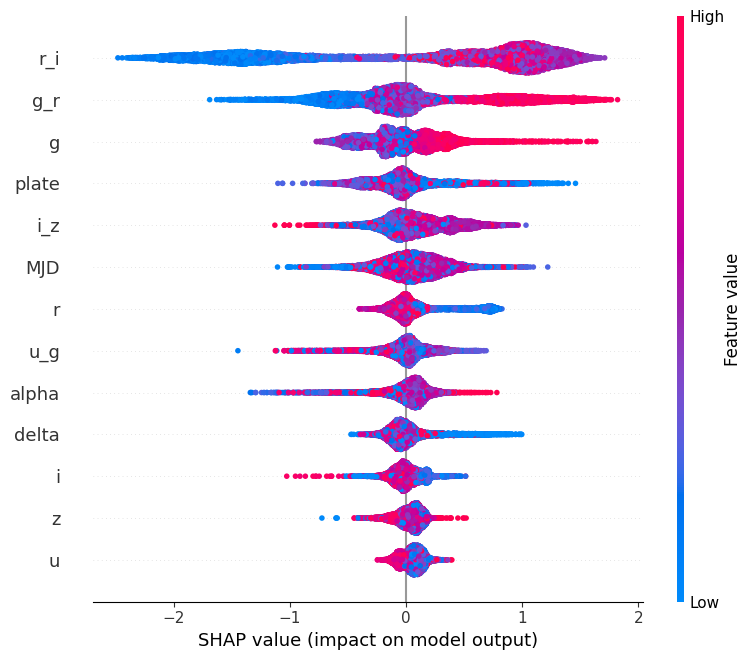


SHAP summary for class: QSO


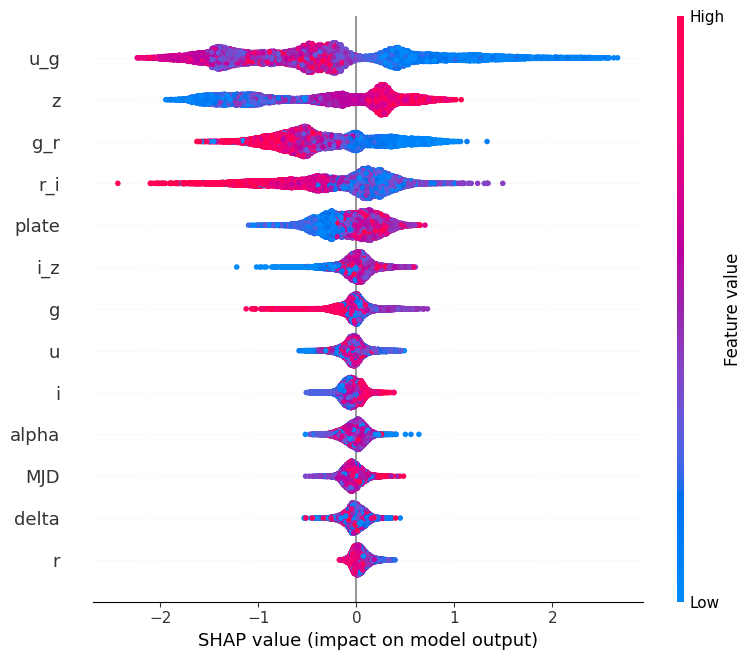


SHAP summary for class: STAR


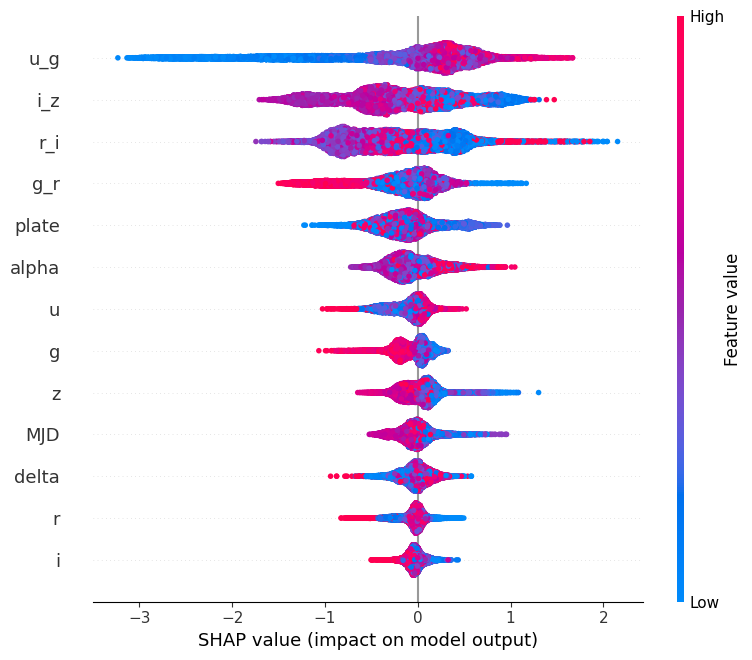

In [16]:
shap_values_xgb = sc.shap_summary_tree_model(
    model=xgb_final,
    X=X_test,
    feature_names=feature_names,
    class_names=label_encoder.classes_
)

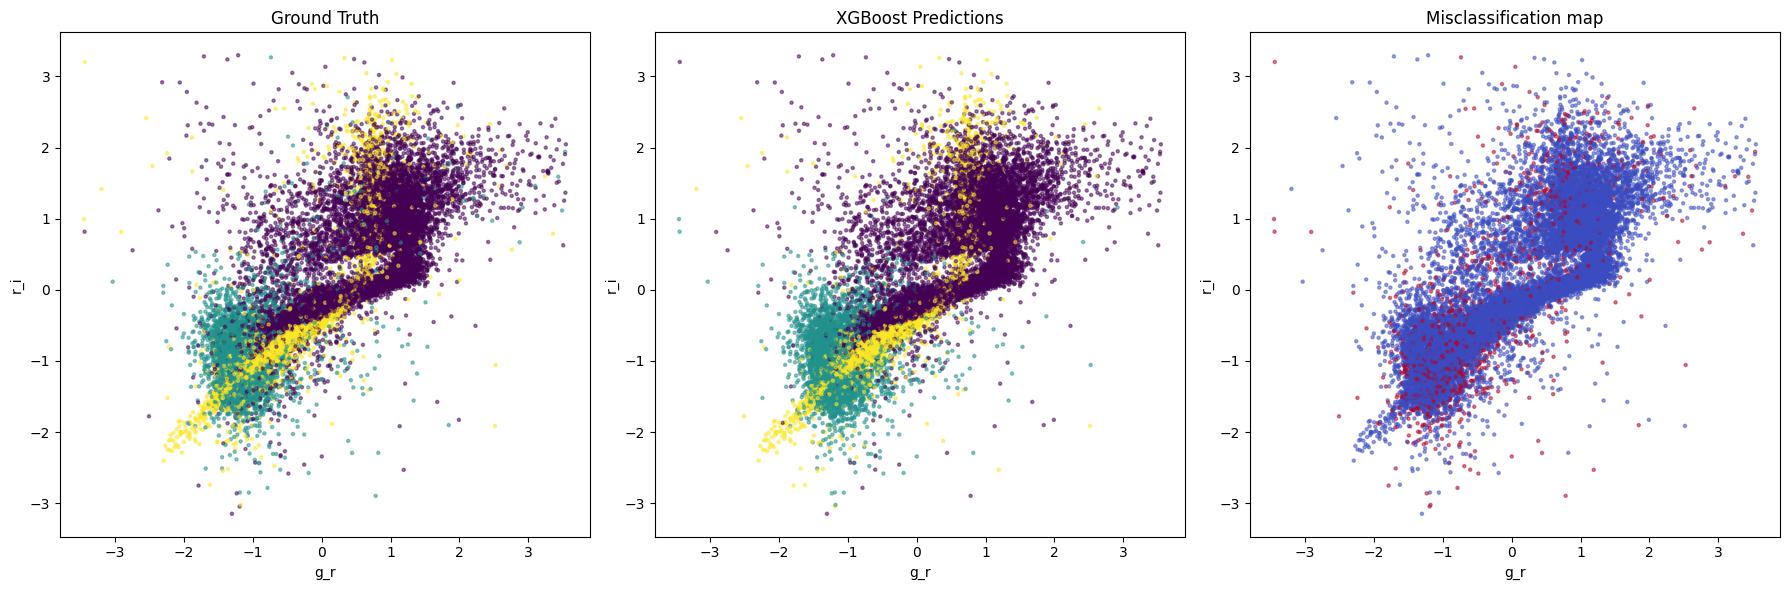

In [17]:
X_test_df = pd.DataFrame(X_test, columns=feature_names)
sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    feature_x="g_r",
    feature_y="r_i",
    title_prefix="XGBoost"
)

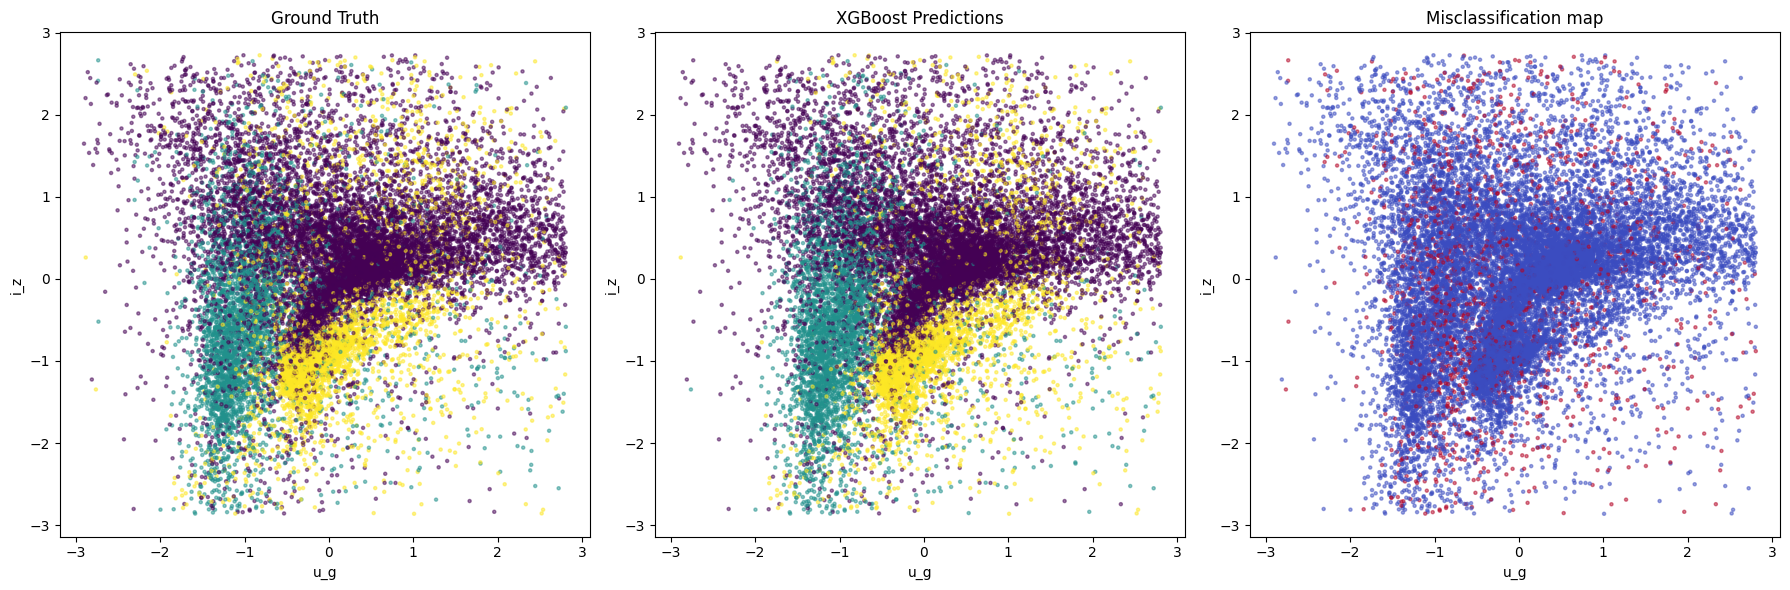

In [18]:
sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    feature_x="u_g",
    feature_y="i_z",
    title_prefix="XGBoost")

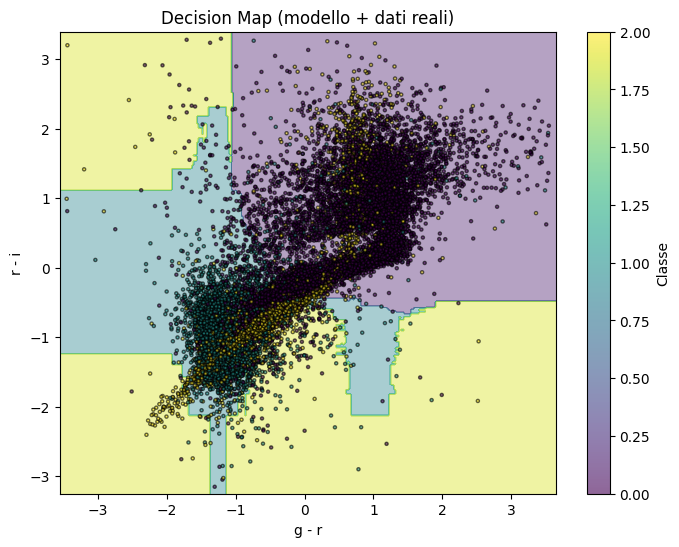

In [19]:
X = X_test_df.copy()   
y = y_test        

# 2. SCELTA PIANO 2D
x_feat = "g_r"
y_feat = "r_i"

x_min, x_max = X[x_feat].min() - 0.1, X[x_feat].max() + 0.1
y_min, y_max = X[y_feat].min() - 0.1, X[y_feat].max() + 0.1

# 3. GRIGLIA
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]


# 4. INPUT MODELLO COMPLETO
# ordine delle feature usate nel modello
feature_names = X.columns

X_dummy = pd.DataFrame(
    np.zeros((grid.shape[0], len(feature_names))),
    columns=feature_names
)

# inserisci le 2 feature del piano
X_dummy[x_feat] = grid[:, 0]
X_dummy[y_feat] = grid[:, 1]

# riempi le altre con la media (approssimazione standard)
for col in feature_names:
    if col not in [x_feat, y_feat]:
        X_dummy[col] = X[col].mean()


# 5. PREDIZIONE
Z = xgb_final.predict(X_dummy)
Z = Z.reshape(xx.shape)

# 6. PLOT
plt.figure(figsize=(8,6))

# decision boundary del modello
plt.contourf(xx, yy, Z, alpha=0.4, cmap="viridis")

# punti reali
plt.scatter( X[x_feat], X[y_feat],  c=y, s=5, cmap="viridis", edgecolor="k", alpha=0.6)

plt.xlabel("g - r")
plt.ylabel("r - i")
plt.title("Decision Map (modello + dati reali)")
plt.colorbar(label="Classe")
plt.show()

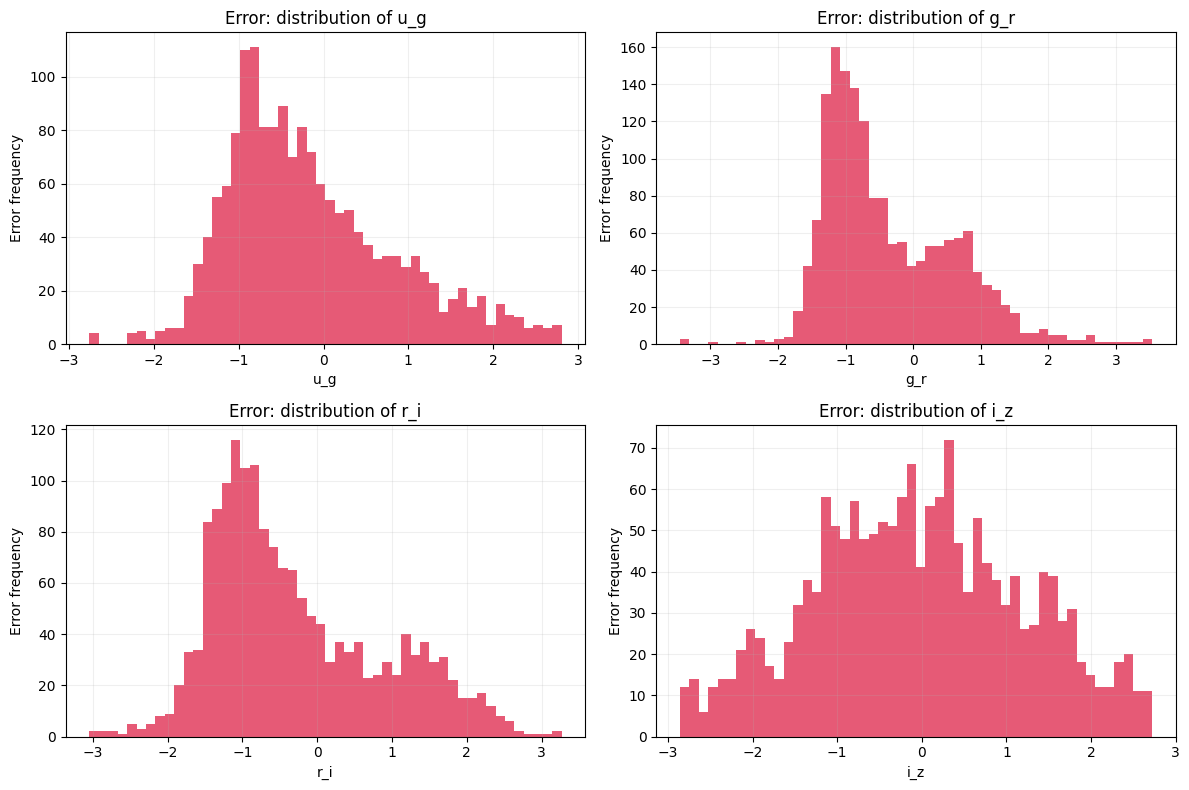

In [20]:
sc.plot_misclassified_feature_distributions(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    features=["u_g", "g_r", "r_i", "i_z"]
)

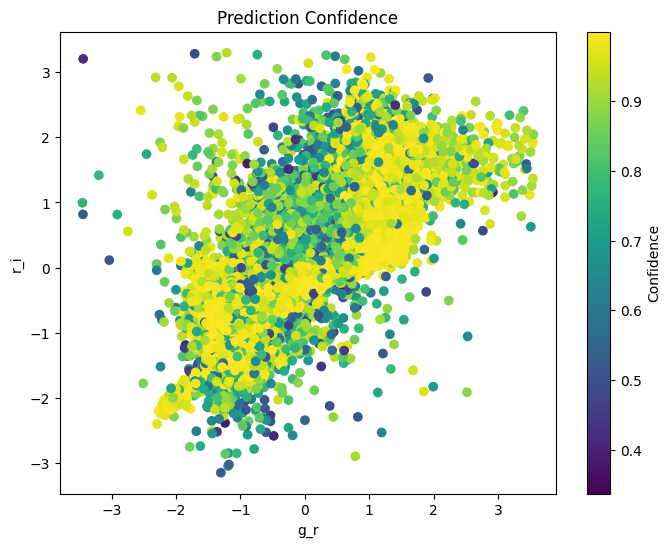

In [21]:
results_xgb = sc.predict_with_confidence(
    model=xgb_final,
    X_test=X_test,
    X_plot=X,
    threshold=0.9,
)

final_pred_xgb = results_xgb["final_predictions"]
confidence_xgb = results_xgb["confidence"]

(array([ 24.,  46., 189., 185., 212., 181., 189., 192., 205., 238.]),
 array([0.34727702, 0.41249937, 0.47772175, 0.54294413, 0.60816646,
        0.67338884, 0.73861122, 0.8038336 , 0.86905599, 0.93427837,
        0.99950075]),
 <BarContainer object of 10 artists>)

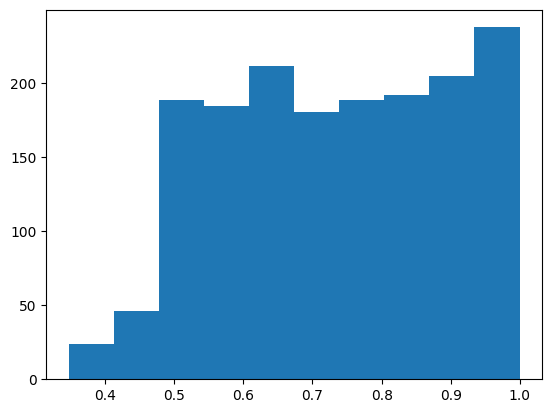

In [22]:
errors_xgb = y_test != y_test_pred_xgb

plt.hist(confidence_xgb[errors_xgb])

## LightGBM

In [14]:
import os
os.environ["LIGHTGBM_VERBOSITY"] = "-1"
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_jobs=3,verbose=-1)
params = {"n_estimators": [30, 50],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "num_leaves": [15, 31], 
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10], 
  } 
   
best_model_lgbm, best_params_lgbm, best_score_lgbm = sc.tune_model(
    lgbm,
    params,
    X_train,
    y_train,verbose=False
)

print("Best Hyperparameters:", best_params_lgbm)

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid featur

Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 1, 'num_leaves': 31, 'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [15]:
best_params_lgbm.pop("n_estimators", None)
lgbm_final = LGBMClassifier(**best_params_lgbm,n_estimators=1000,verbose=-1 )

import lightgbm as lgb
lgbm_final.fit(X_train, y_train,eval_set=[(X_val, y_val)],  eval_metric='multi_logloss',  callbacks=[lgb.early_stopping(50)])

train_metrics_lgbm, val_metrics_lgbm = sc.evaluate_single_model(
    lgbm_final,
    X_train, y_train,
    X_val, y_val,
    model_name="LightGBM Tuned"
)

y_test_pred_lgbm = lgbm_final.predict(X_test)
lgbm_metrics = sc.evaluate_test_set(y_test, y_test_pred_lgbm, "LightGBM")
sc.print_metrics(lgbm_metrics)

X_test_df = pd.DataFrame(X_test, columns=feature_names)


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[551]	valid_0's multi_logloss: 0.280287


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[Training] Acc=94.6080% P=0.9462 R=0.9461 F1=0.9461
Confusion Matrix:
[[31066   725   553]
 [ 1107 30374   863]
 [  766  1218 30360]]

[Validation] Acc=90.5790% P=0.8769 R=0.8825 F1=0.8792
Confusion Matrix:
[[10174   350   257]
 [  229  3080   239]
 [  264   381  3283]]



/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM:
  Accuracy  : 90.81%
  Precision: 0.8794
  Recall   : 0.8847
  F1       : 0.8817
  Confusion Matrix:
[[10197   344   240]
 [  230  3063   255]
 [  247   362  3319]]


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid featur

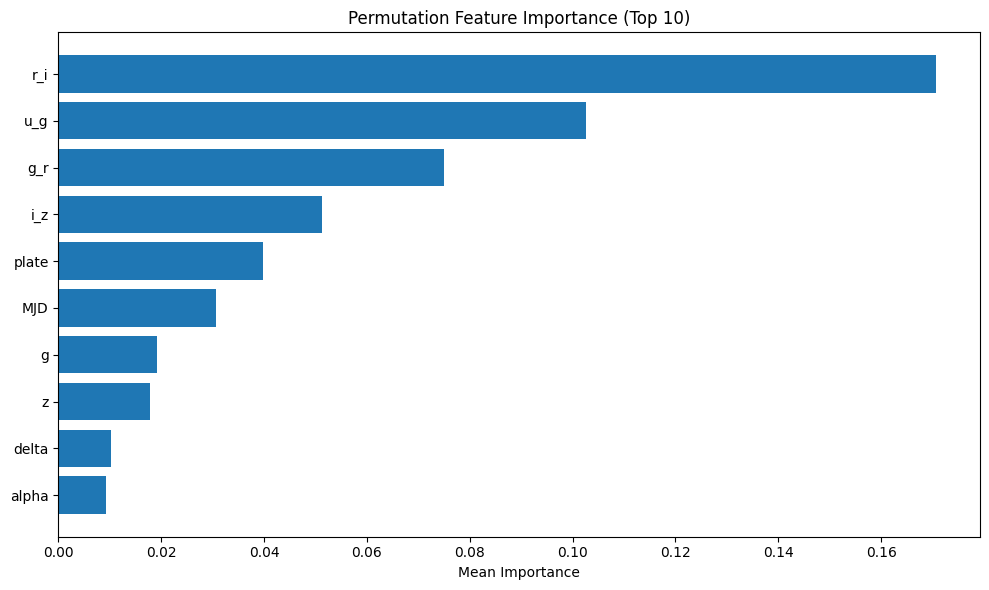

Feature Importance Scores:
r_i: 0.1707
u_g: 0.1027
g_r: 0.0750
i_z: 0.0512
plate: 0.0398
MJD: 0.0306
g: 0.0191
z: 0.0178
delta: 0.0102
alpha: 0.0092
i: 0.0078
r: 0.0054
u: 0.0050


In [25]:
# Feature Importance (using permutation importance on the LGBM Classifier)
imp_lgbm = sc.compute_permutation_importance(lgbm_final, X_test, y_test, feature_names=feature_names)
sc.plot_permutation_importance(imp_lgbm, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp_lgbm.items():
    print(f"{feat}: {val:.4f}")


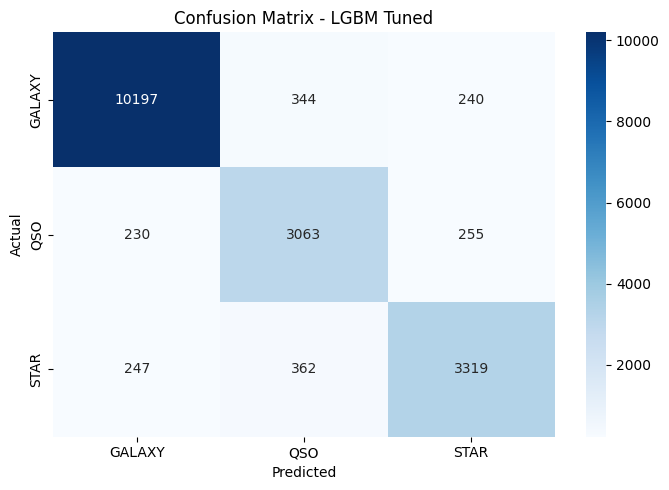

In [26]:
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(lgbm_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - LGBM Tuned')


SHAP summary for class: GALAXY


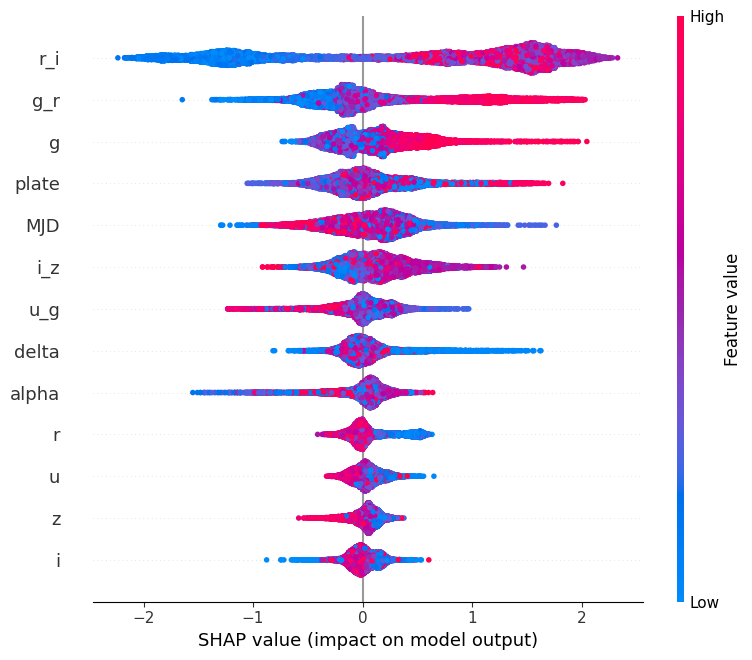


SHAP summary for class: QSO


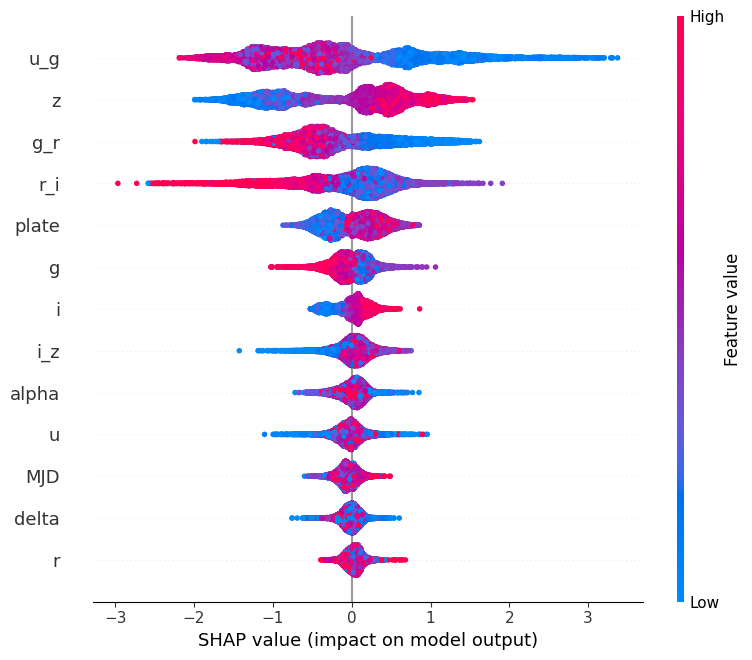


SHAP summary for class: STAR


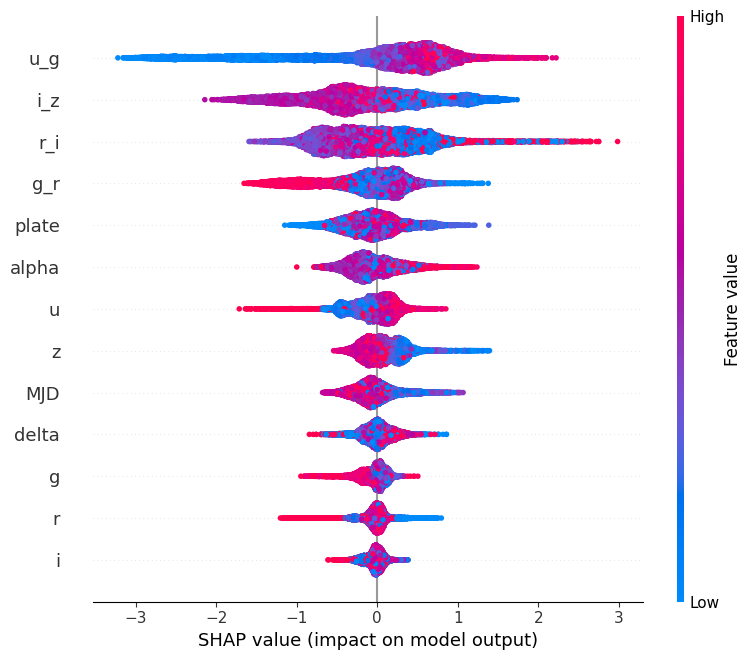

In [27]:
shap_values_lgbm = sc.shap_summary_tree_model(
    model=lgbm_final,
    X=X_test,
    feature_names=feature_names,
    class_names=label_encoder.classes_
)

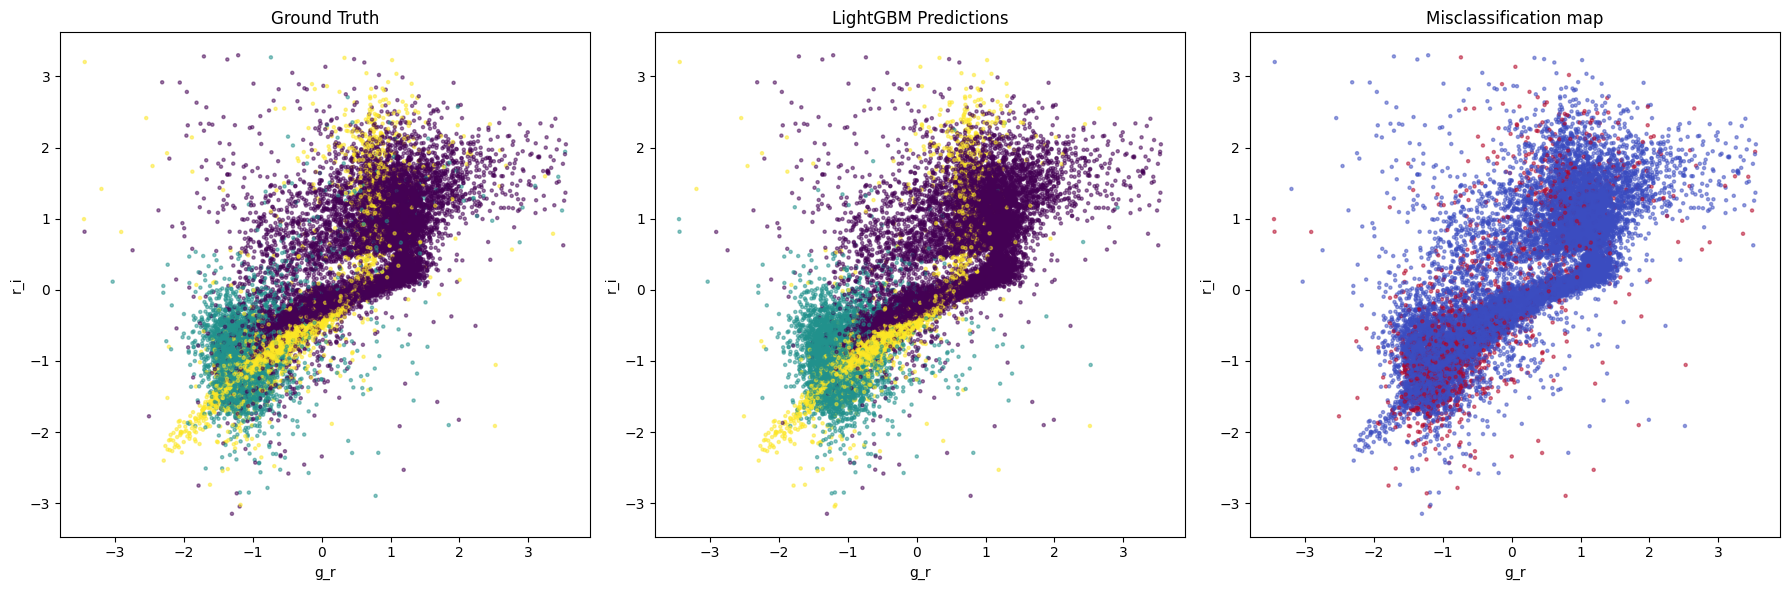

In [28]:
X_test_df = pd.DataFrame(X_test, columns=feature_names)
sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_lgbm,
    feature_x="g_r",
    feature_y="r_i",
    title_prefix="LightGBM"
)

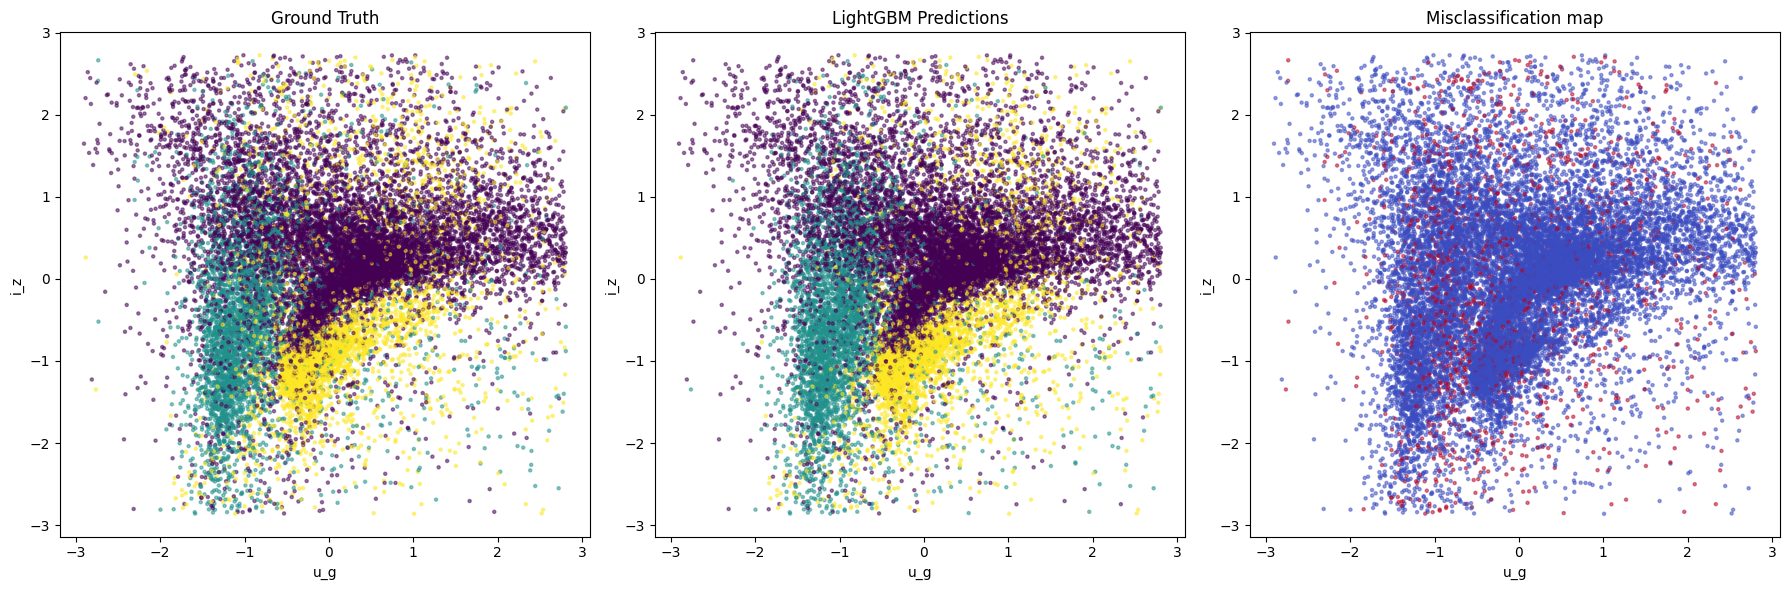

In [29]:
X_test_df = pd.DataFrame(X_test, columns=feature_names)
sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_lgbm,
    feature_x="u_g",
    feature_y="i_z",
    title_prefix="LightGBM"
)

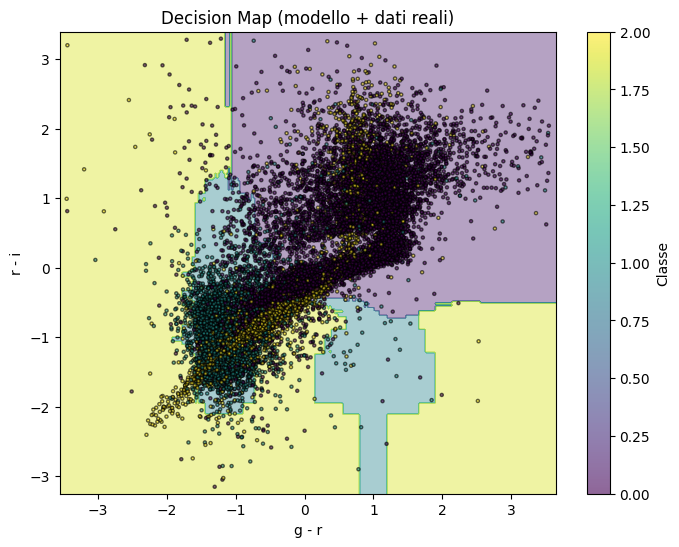

In [30]:
X = X_test_df.copy()   
y = y_test        

# 2. SCELTA PIANO 2D
x_feat = "g_r"
y_feat = "r_i"

x_min, x_max = X[x_feat].min() - 0.1, X[x_feat].max() + 0.1
y_min, y_max = X[y_feat].min() - 0.1, X[y_feat].max() + 0.1

# 3. GRIGLIA
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]


# 4. INPUT MODELLO COMPLETO
# ordine delle feature usate nel modello
feature_names = X.columns

X_dummy = pd.DataFrame(
    np.zeros((grid.shape[0], len(feature_names))),
    columns=feature_names
)

# inserisci le 2 feature del piano
X_dummy[x_feat] = grid[:, 0]
X_dummy[y_feat] = grid[:, 1]

# riempi le altre con la media (approssimazione standard)
for col in feature_names:
    if col not in [x_feat, y_feat]:
        X_dummy[col] = X[col].mean()


# 5. PREDIZIONE
Z = lgbm_final.predict(X_dummy)
Z = Z.reshape(xx.shape)

# 6. PLOT
plt.figure(figsize=(8,6))

# decision boundary del modello
plt.contourf(xx, yy, Z, alpha=0.4, cmap="viridis")

# punti reali
plt.scatter( X[x_feat], X[y_feat],  c=y, s=5, cmap="viridis", edgecolor="k", alpha=0.6)

plt.xlabel("g - r")
plt.ylabel("r - i")
plt.title("Decision Map (modello + dati reali)")
plt.colorbar(label="Classe")
plt.show()

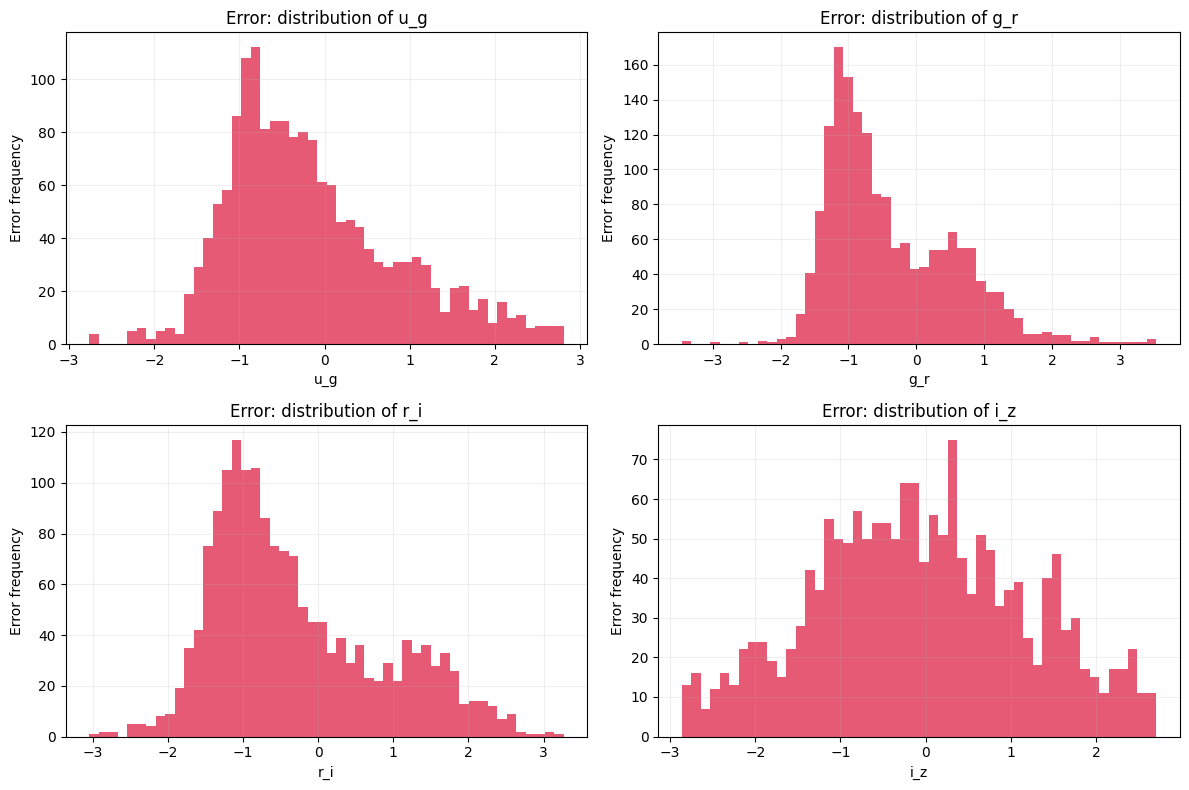

In [31]:
sc.plot_misclassified_feature_distributions(
    X_test_df,
    y_test,
    y_test_pred_lgbm,
    features=["u_g", "g_r", "r_i", "i_z"]
)

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


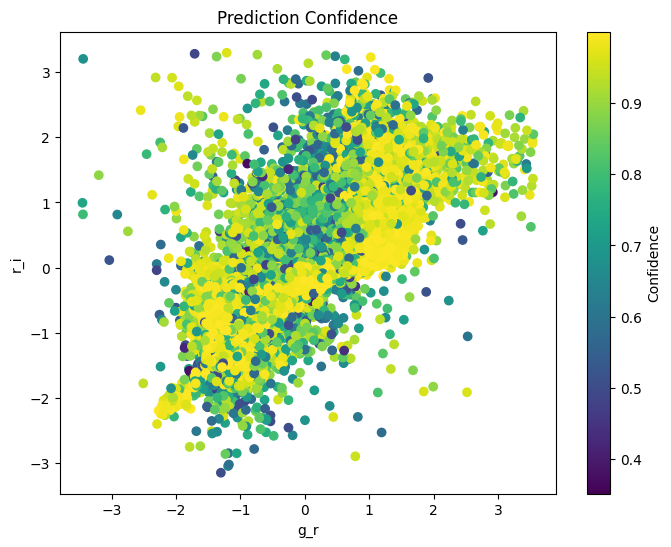

In [32]:
results_lgbm = sc.predict_with_confidence(
    model=lgbm_final,
    X_test=X_test,
    X_plot=X,
    threshold=0.9,
)

final_pred_lgbm = results_lgbm["final_predictions"]
confidence_lgbm = results_lgbm["confidence"]

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid featur

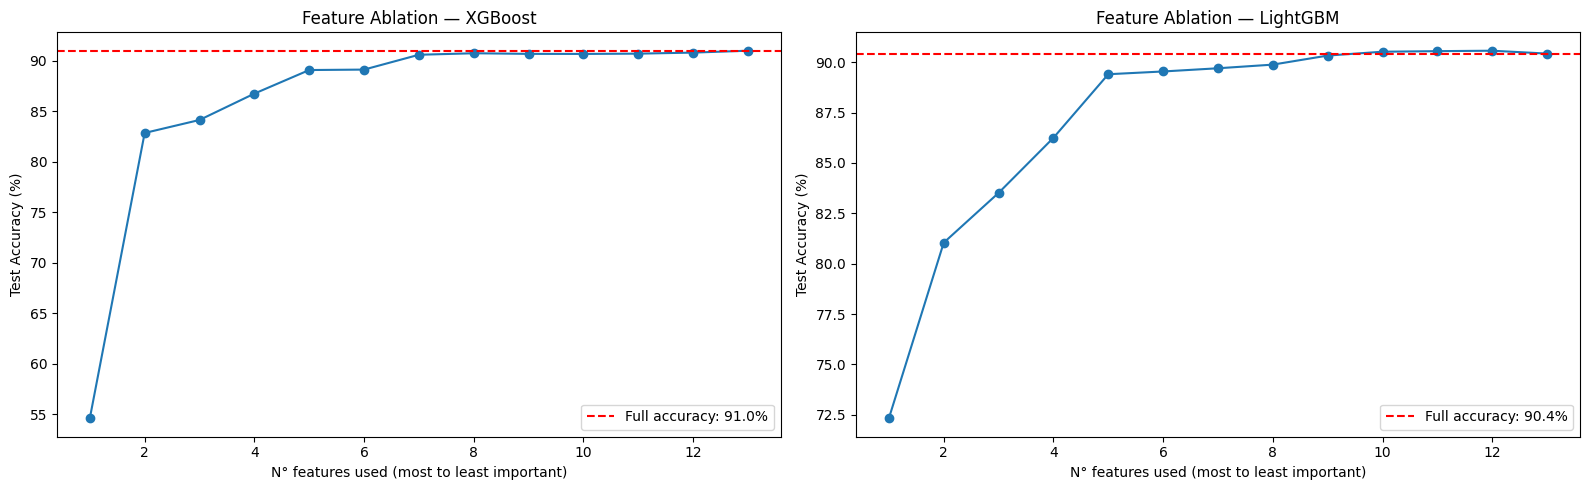

In [ ]:
#feature ablation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

xgb_ablation = XGBClassifier(
    n_estimators=200,   
    max_depth=xgb_final.max_depth,
    learning_rate=xgb_final.learning_rate,
    subsample=xgb_final.subsample,
    colsample_bytree=xgb_final.colsample_bytree,
    random_state=42
)
xgb_ablation.fit(X_train, y_train)
sc.plot_feature_ablation(xgb_ablation, X_train, X_test, y_train, y_test,
                         feature_names, 
                         title='Feature Ablation — XGBoost',
                         ax=axes[0])


lgbm_ablation = LGBMClassifier(
    n_estimators=200,
    max_depth=lgbm_final.max_depth,
    learning_rate=lgbm_final.learning_rate,
    subsample=lgbm_final.subsample,
    colsample_bytree=lgbm_final.colsample_bytree,
    reg_alpha=lgbm_final.reg_alpha,
    reg_lambda=lgbm_final.reg_lambda,
)
lgbm_ablation.fit(X_train, y_train)
sc.plot_feature_ablation(lgbm_ablation, X_train, X_test, y_train, y_test,
                         feature_names,
                         title='Feature Ablation — LightGBM',
                         ax=axes[1])

plt.tight_layout()
plt.show()

## Only physical features with new colors

In [50]:
star["u_r"] = star["u"] - star["r"]
star["g_i"] = star["g"] - star["i"]
star["r_z"] = star["r"] - star["z"]

star_new = star.drop(columns=['plate','MJD','alpha','delta'])
star_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   u            100000 non-null  float64
 2   g            100000 non-null  float64
 3   r            100000 non-null  float64
 4   i            100000 non-null  float64
 5   z            100000 non-null  float64
 6   run_ID       100000 non-null  int64  
 7   rerun_ID     100000 non-null  int64  
 8   cam_col      100000 non-null  int64  
 9   field_ID     100000 non-null  int64  
 10  spec_obj_ID  100000 non-null  float64
 11  class        100000 non-null  str    
 12  redshift     100000 non-null  float64
 13  fiber_ID     100000 non-null  int64  
 14  u_g          100000 non-null  float64
 15  g_r          100000 non-null  float64
 16  r_i          100000 non-null  float64
 17  i_z          100000 non-null  float64
 18  u_r          100000 non-null  float6

In [51]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train_new, X_val_new, X_test_new, y_train_new, y_val_new, y_test_new, label_encoder_new, scaler_new, feature_names_new = sc.prepare_splits(
    star_new, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train_new.shape}")
print(f"X_val shape: {X_val_new.shape}")
print(f"X_test shape: {X_test_new.shape}")


# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train_new, y_train_new, 
    X_val_new, y_val_new, 
    X_test_new, y_test_new, 
    batch_size=64
)

print("DataLoaders created.")

Outliers removed: 8,748 rows  (91,252 remain)
X_train shape: (97002, 12)
X_val shape: (18251, 12)
X_test shape: (18251, 12)
DataLoaders created.


In [52]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

params = {"n_estimators": [30, 50],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10],
}

best_model_xgb_new, best_params_xgb_new, best_score_xgb_new = sc.tune_model(
    xgb,
    params,
    X_train_new,
    y_train_new,
)

print("Best Hyperparameters:", best_params_xgb_new)

Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 30, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 1.0}


In [53]:
best_params_xgb_new.pop("n_estimators", None)

xgb_final_new = XGBClassifier(**best_params_xgb_new,n_estimators=500, objective="multi:softprob",
    eval_metric="mlogloss",
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=42)
xgb_final_new.fit(X_train_new, y_train_new ,eval_set=[(X_val_new, y_val_new)],verbose=False)

train_metrics_xgb_new, val_metrics_xgb_new = sc.evaluate_single_model(
    xgb_final_new,
    X_train_new, y_train_new,
    X_val_new, y_val_new,
    model_name="XGBoost Tuned"
)

y_test_pred_xgb_new = xgb_final_new.predict(X_test_new)
xgb_metrics_new = sc.evaluate_test_set(y_test_new, y_test_pred_xgb_new, "XGBoost")
sc.print_metrics(xgb_metrics_new )
X_test_df_new = pd.DataFrame(X_test_new, columns=feature_names_new)


[Training] Acc=93.0177% P=0.9303 R=0.9302 F1=0.9301
Confusion Matrix:
[[30646   829   859]
 [ 1157 30024  1153]
 [ 1526  1249 29559]]

[Validation] Acc=88.6308% P=0.8527 R=0.8641 F1=0.8581
Confusion Matrix:
[[9938  401  439]
 [ 263 2989  296]
 [ 320  356 3249]]


XGBoost:
  Accuracy  : 89.07%
  Precision: 0.8594
  Recall   : 0.8695
  F1       : 0.8641
  Confusion Matrix:
[[9972  400  406]
 [ 266 3043  239]
 [ 323  361 3241]]


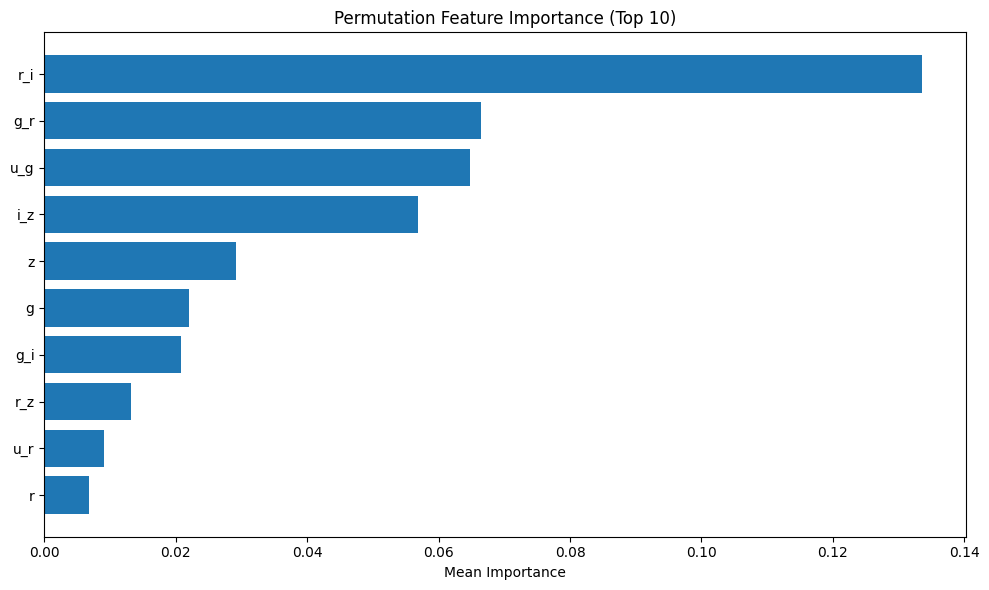

Feature Importance Scores:
r_i: 0.1336
g_r: 0.0664
u_g: 0.0648
i_z: 0.0569
z: 0.0292
g: 0.0220
g_i: 0.0208
r_z: 0.0132
u_r: 0.0090
r: 0.0068
i: 0.0055
u: 0.0010


In [54]:
# Feature Importance (using permutation importance on the XGBoost Classifier)
imp_xgb_new = sc.compute_permutation_importance(xgb_final_new, X_test_new, y_test_new, feature_names=feature_names_new)
sc.plot_permutation_importance(imp_xgb_new, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp_xgb_new.items():
    print(f"{feat}: {val:.4f}")


In [55]:
shap_values_xgb_new = sc.shap_summary_tree_model(
    model=xgb_final_new,
    X=X_test_new,
    feature_names=feature_names_new,
    class_names=label_encoder_new.classes_
)

KeyboardInterrupt: 

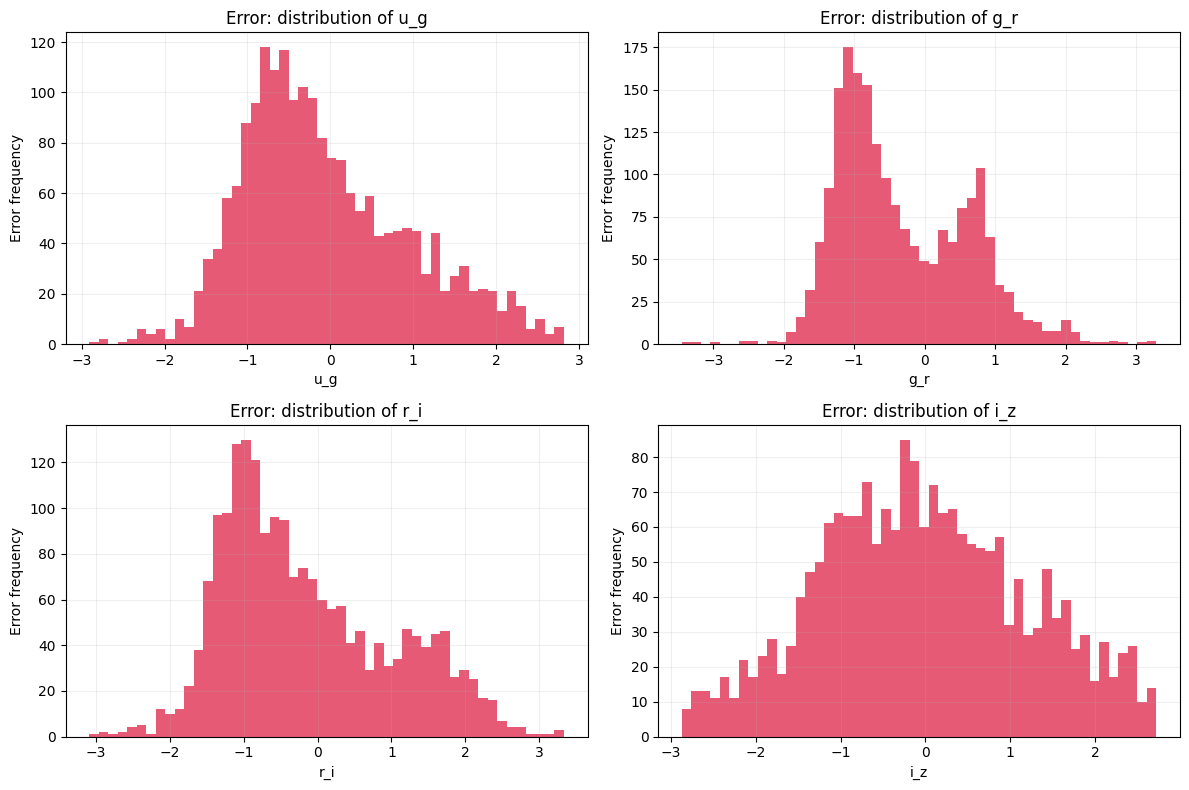

In [56]:
sc.plot_misclassified_feature_distributions(
    X_test_df_new,
    y_test_new,
    y_test_pred_xgb_new,
    features=["u_g", "g_r", "r_i", "i_z",]
)

In [57]:
import os
os.environ["LIGHTGBM_VERBOSITY"] = "-1"
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_jobs=3,verbose=-1)
params = {"n_estimators": [30, 50],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "num_leaves": [15, 31], 
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10], 
  } 
   
best_model_lgbm_new, best_params_lgbm_new, best_score_lgbm_new = sc.tune_model(
    lgbm,
    params,
    X_train_new,
    y_train_new,verbose=False
)

print("Best Hyperparameters:", best_params_lgbm_new)

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid featur

Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 1, 'num_leaves': 31, 'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [58]:
best_params_lgbm_new.pop("n_estimators", None)
lgbm_final_new = LGBMClassifier(**best_params_lgbm_new,n_estimators=1000,verbose=-1 )

import lightgbm as lgb
lgbm_final_new.fit(X_train_new, y_train_new,eval_set=[(X_val_new, y_val_new)],  eval_metric='multi_logloss',  callbacks=[lgb.early_stopping(50)])

train_metrics_lgbm, val_metrics_lgbm = sc.evaluate_single_model(
    lgbm_final_new,
    X_train_new, y_train_new,
    X_val_new, y_val_new,
    model_name="LightGBM Tuned"
)

y_test_pred_lgbm_new = lgbm_final_new.predict(X_test_new)
lgbm_metrics_new = sc.evaluate_test_set(y_test_new, y_test_pred_lgbm_new, "LightGBM")
sc.print_metrics(lgbm_metrics_new)

X_test_df_new = pd.DataFrame(X_test_new, columns=feature_names_new)


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[388]	valid_0's multi_logloss: 0.326331


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[Training] Acc=91.3146% P=0.9133 R=0.9131 F1=0.9130
Confusion Matrix:
[[30385   953   996]
 [ 1468 29366  1500]
 [ 1736  1772 28826]]

[Validation] Acc=88.6746% P=0.8531 R=0.8666 F1=0.8595
Confusion Matrix:
[[9906  413  459]
 [ 256 3004  288]
 [ 308  343 3274]]



/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM:
  Accuracy  : 88.86%
  Precision: 0.8556
  Recall   : 0.8698
  F1       : 0.8622
  Confusion Matrix:
[[9909  433  436]
 [ 250 3051  247]
 [ 305  362 3258]]


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid featur

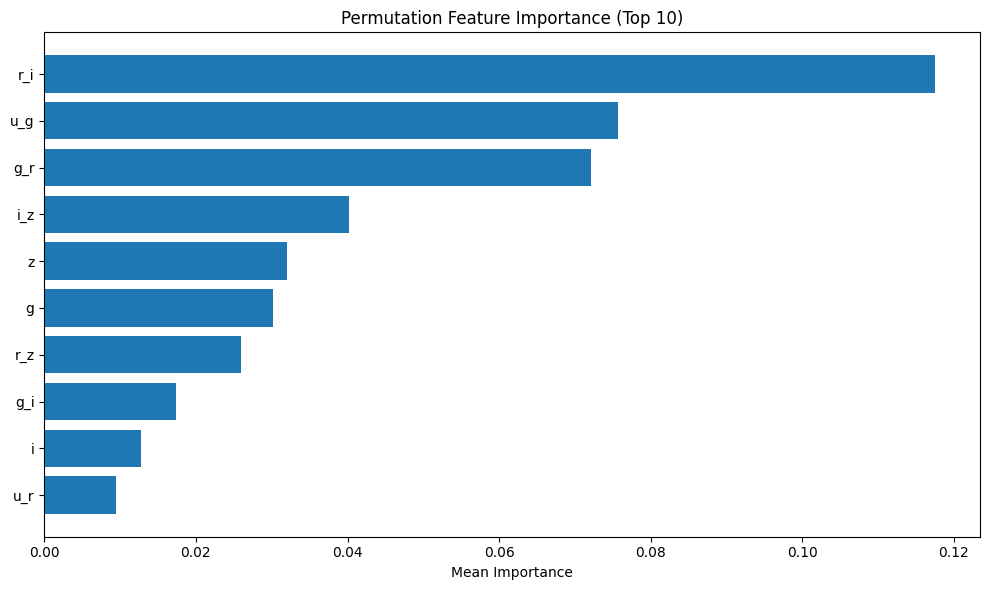

Feature Importance Scores:
r_i: 0.1176
u_g: 0.0757
g_r: 0.0721
i_z: 0.0402
z: 0.0320
g: 0.0302
r_z: 0.0259
g_i: 0.0174
i: 0.0127
u_r: 0.0095
r: 0.0093
u: 0.0038


In [59]:
# Feature Importance (using permutation importance on the LGBM Classifier)
imp_lgbm_new = sc.compute_permutation_importance(lgbm_final_new, X_test_new, y_test_new, feature_names=feature_names_new)
sc.plot_permutation_importance(imp_lgbm_new, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp_lgbm_new.items():
    print(f"{feat}: {val:.4f}")


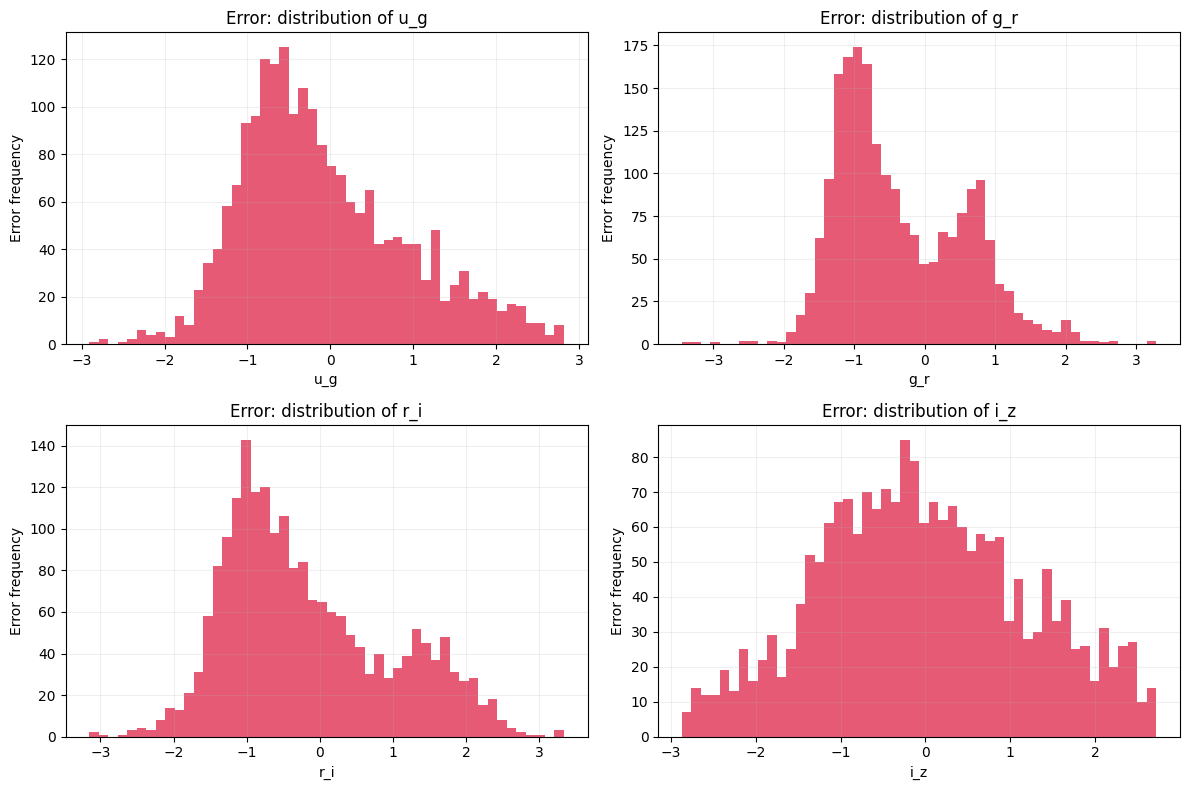

In [60]:
sc.plot_misclassified_feature_distributions(
    X_test_df_new,
    y_test_new,
    y_test_pred_lgbm_new,
    features=["u_g", "g_r", "r_i", "i_z"]
)

## Only color features

In [79]:
star_c = star_new.drop(columns=['u','g','r','i','z'])

# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train_c, X_val_c, X_test_c, y_train_c, y_val_c, y_test_c, label_encoder_c, scaler_c, feature_names_c = sc.prepare_splits(
    star_c, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train_c.shape}")
print(f"X_val shape: {X_val_c.shape}")
print(f"X_test shape: {X_test_c.shape}")


# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train_c, y_train_c, 
    X_val_c, y_val_c, 
    X_test_c, y_test_c, 
    batch_size=64
)

print("DataLoaders created.")

Outliers removed: 8,525 rows  (91,475 remain)
X_train shape: (97365, 7)
X_val shape: (18295, 7)
X_test shape: (18295, 7)
DataLoaders created.


In [80]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

params = {"n_estimators": [30, 50],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10],
}

best_model_xgb_c, best_params_xgb_c, best_score_xgb_c = sc.tune_model(
    xgb,
    params,
    X_train_c,
    y_train_c,
)

print("Best Hyperparameters:", best_params_xgb_c)

Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 30, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 1.0}


In [81]:
best_params_xgb_c.pop("n_estimators", None)

xgb_final_c = XGBClassifier(**best_params_xgb_c,n_estimators=500, objective="multi:softprob",
    eval_metric="mlogloss",
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=42)
xgb_final_c.fit(X_train_c, y_train_c ,eval_set=[(X_val_c, y_val_c)],verbose=False)

train_metrics_xgb_c, val_metrics_xgb_c = sc.evaluate_single_model(
    xgb_final_c,
    X_train_c, y_train_c,
    X_val_c, y_val_c,
    model_name="XGBoost Tuned"
)

y_test_pred_xgb_c = xgb_final_c.predict(X_test_c)
xgb_metrics_c = sc.evaluate_test_set(y_test_c, y_test_pred_xgb_c, "XGBoost")
sc.print_metrics(xgb_metrics_c )
X_test_df_c = pd.DataFrame(X_test_c, columns=feature_names_c)


[Training] Acc=89.0731% P=0.8911 R=0.8907 F1=0.8907
Confusion Matrix:
[[29588  1216  1651]
 [ 1821 28965  1669]
 [ 2483  1799 28173]]

[Validation] Acc=85.9142% P=0.8197 R=0.8391 F1=0.8286
Confusion Matrix:
[[9654  479  686]
 [ 278 2976  292]
 [ 415  427 3088]]


XGBoost:
  Accuracy  : 86.38%
  Precision: 0.8256
  Recall   : 0.8477
  F1       : 0.8357
  Confusion Matrix:
[[9634  443  742]
 [ 235 2999  312]
 [ 391  368 3171]]


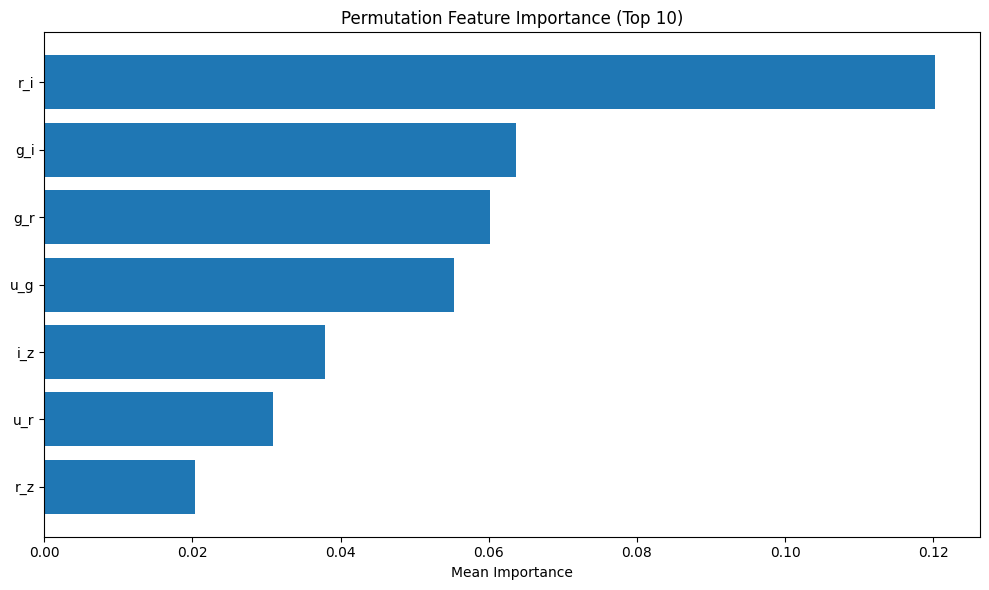

Feature Importance Scores:
r_i: 0.1203
g_i: 0.0637
g_r: 0.0601
u_g: 0.0553
i_z: 0.0379
u_r: 0.0308
r_z: 0.0203


In [82]:
# Feature Importance (using permutation importance on the XGBoost Classifier)
imp_xgb_c = sc.compute_permutation_importance(xgb_final_c, X_test_c, y_test_c, feature_names=feature_names_c)
sc.plot_permutation_importance(imp_xgb_c, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp_xgb_c.items():
    print(f"{feat}: {val:.4f}")
